<a href="https://colab.research.google.com/github/Despectinator/AIML-Internship-Muhammad-Ali/blob/main/Lab_14_Muhammad_Ali_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 14 (Week 3 — Lab 4): Recurrent Neural Networks & Sequence Data

Welcome to Lab 14! In this lab you will build a Recurrent Neural Network (using LSTM) for text classification — predicting whether a movie review is positive or negative.

**For detailed theory on RNNs, LSTMs, and sequence preparation, see the Lab 14 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.
- Training on sequence data can take a few minutes per run — be patient.

## Getting the Dataset

This lab uses the IMDB Movie Reviews dataset, built directly into Keras — no download or upload needed. Reviews are already converted to sequences of word-index integers.

In [1]:
from tensorflow import keras
import numpy as np

vocab_size = 10000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

print("Training reviews:", len(X_train))
print("Test reviews:", len(X_test))
print("First review (word indices):", X_train[0][:20])
print("First review's label (0=negative, 1=positive):", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training reviews: 25000
Test reviews: 25000
First review (word indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First review's label (0=negative, 1=positive): 1


## Decoding a Review Back to Words

Just to see what the data actually represents, here's how to turn word indices back into readable text.

In [2]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

print(decode_review(X_train[0]))
print("\nLabel:", "Positive" if y_train[0] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these c

## Preparing the Data: Padding Sequences

Reviews vary in length, but the network needs a fixed input size. We'll pad/truncate every review to 200 words.

In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

maxlen = 200
X_train_padded = pad_sequences(X_train, maxlen=maxlen)
X_test_padded = pad_sequences(X_test, maxlen=maxlen)

print("Padded shape:", X_train_padded.shape)
print("Example padded review:", X_train_padded[0][:20], "...")

Padded shape: (25000, 200)
Example padded review: [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2] ...


## Example 1: Building an LSTM Model

In [4]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

## Example 2: Compiling & Training

To keep training time reasonable, we'll train on a subset first.

In [5]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_padded[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.6861 - loss: 0.5802 - val_accuracy: 0.8395 - val_loss: 0.3884
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.8845 - loss: 0.2994 - val_accuracy: 0.8140 - val_loss: 0.3975
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.9342 - loss: 0.1888 - val_accuracy: 0.8665 - val_loss: 0.3232
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.9606 - loss: 0.1197 - val_accuracy: 0.8545 - val_loss: 0.3446
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.9714 - loss: 0.0888 - val_accuracy: 0.8690 - val_loss: 0.3833


## Example 3: Visualizing Training Progress

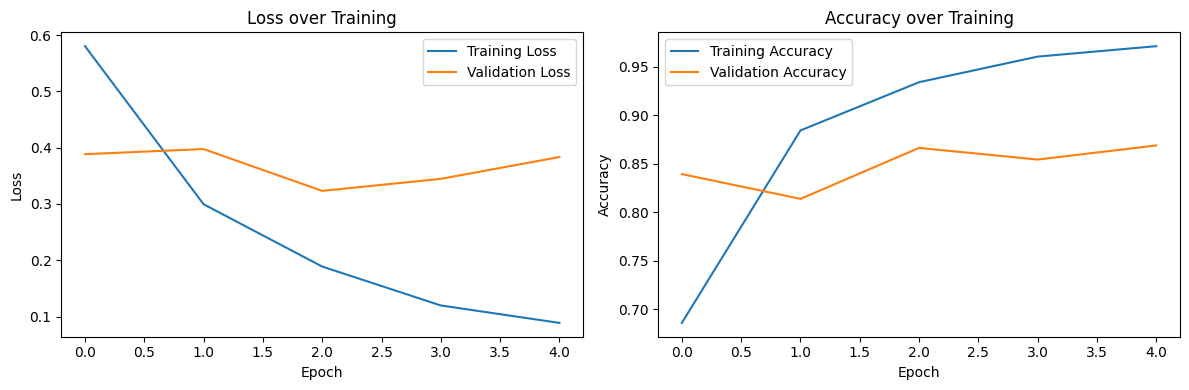

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Training")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Training")

plt.tight_layout()
plt.show()

## Example 4: Evaluating and Predicting on New Reviews

In [7]:
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

sample_predictions = model.predict(X_test_padded[:5], verbose=0)
for i in range(5):
    sentiment = "Positive" if sample_predictions[i][0] > 0.5 else "Negative"
    actual = "Positive" if y_test[i] == 1 else "Negative"
    print(f"Predicted: {sentiment} ({sample_predictions[i][0]:.2f}) | Actual: {actual}")

Test Accuracy: 0.8457
Predicted: Negative (0.08) | Actual: Negative
Predicted: Positive (1.00) | Actual: Positive
Predicted: Positive (0.99) | Actual: Positive
Predicted: Negative (0.07) | Actual: Negative
Predicted: Positive (1.00) | Actual: Positive


## Practice Exercise 1: Try a GRU Instead of LSTM

**Exercise:** Rebuild the model from Example 1, but replace `layers.LSTM(32)` with `layers.GRU(32)`. Train on the same 10,000-review subset for 5 epochs and compare test accuracy and training time to the LSTM version.

In [8]:
model_gru = None
test_accuracy_gru = None

### YOUR CODE HERE ###
import time

model_gru = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.GRU(32),
    layers.Dense(1, activation="sigmoid")
])

model_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start_gru = time.time()
history_gru = model_gru.fit(
    X_train_padded[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
time_gru = time.time() - start_gru

test_loss_gru, test_accuracy_gru = model_gru.evaluate(X_test_padded, y_test, verbose=0)
print(f"GRU training time: {time_gru:.1f}s")
### END ###

print("Test accuracy (GRU):", test_accuracy_gru)


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - accuracy: 0.6513 - loss: 0.6055 - val_accuracy: 0.8020 - val_loss: 0.4348
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.8651 - loss: 0.3264 - val_accuracy: 0.8545 - val_loss: 0.3468
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.9224 - loss: 0.2036 - val_accuracy: 0.8410 - val_loss: 0.3801
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.9540 - loss: 0.1361 - val_accuracy: 0.8475 - val_loss: 0.4578
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.9685 - loss: 0.0978 - val_accuracy: 0.8360 - val_loss: 0.4618
GRU training time: 69.2s
Test accuracy (GRU): 0.8300399780273438


## Practice Exercise 2: Changing Sequence Length

**Exercise:** Re-pad the reviews using `maxlen=100` instead of 200. Rebuild and retrain the LSTM model from Example 1 with this shorter sequence length. Compare test accuracy and training time to the original.

In [9]:
### YOUR CODE HERE ###
import time

maxlen_short = 100
X_train_padded_100 = pad_sequences(X_train, maxlen=maxlen_short)
X_test_padded_100 = pad_sequences(X_test, maxlen=maxlen_short)

model_len100 = keras.Sequential([
    layers.Input(shape=(maxlen_short,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

model_len100.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start_100 = time.time()
history_len100 = model_len100.fit(
    X_train_padded_100[:10000], y_train[:10000],
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
time_100 = time.time() - start_100

test_loss_100, test_accuracy_100 = model_len100.evaluate(X_test_padded_100, y_test, verbose=0)

print(f"maxlen=200 (Example 1) -> Test accuracy: {test_accuracy:.4f}")
print(f"maxlen=100             -> Test accuracy: {test_accuracy_100:.4f}, Training time: {time_100:.1f}s")
### END ###


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.6991 - loss: 0.5616 - val_accuracy: 0.8150 - val_loss: 0.4226
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.8774 - loss: 0.2993 - val_accuracy: 0.8390 - val_loss: 0.3694
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9371 - loss: 0.1821 - val_accuracy: 0.8070 - val_loss: 0.4438
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.9599 - loss: 0.1238 - val_accuracy: 0.8305 - val_loss: 0.4400
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.9787 - loss: 0.0718 - val_accuracy: 0.8160 - val_loss: 0.6000
maxlen=200 (Example 1) -> Test accuracy: 0.8457
maxlen=100             -> Test accuracy: 0.8060, Training time: 43.3s


## Practice Exercise 3: Predicting Your Own Review

**Exercise:** Write your own short movie review as a Python string (2-3 sentences). Convert it to word indices using the `word_index` dictionary from earlier (map each word to its index, using 2 for unknown words, then add 3 to match the dataset's offset), pad it to `maxlen=200`, and predict its sentiment using your trained model.

In [10]:
my_review = "This movie was absolutely wonderful and I loved every minute of it"

### YOUR CODE HERE ###
words = my_review.lower().split()
encoded_review = [1]  # <START> token
for w in words:
    idx = word_index.get(w, -1)
    if idx == -1 or idx + 3 >= vocab_size:
        encoded_review.append(2)  # <UNK>
    else:
        encoded_review.append(idx + 3)

my_review_padded = pad_sequences([encoded_review], maxlen=maxlen)

my_prediction = model.predict(my_review_padded, verbose=0)
sentiment = "Positive" if my_prediction[0][0] > 0.5 else "Negative"

print(f"Review: {my_review}")
print(f"Predicted sentiment: {sentiment} (score: {my_prediction[0][0]:.4f})")
### END ###


Review: This movie was absolutely wonderful and I loved every minute of it
Predicted sentiment: Positive (score: 0.8563)


## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Build & Train Your Own Model**: Design your own architecture (try stacking 2 LSTM layers, or changing the embedding/LSTM unit sizes). Train on at least 10,000 reviews and report test accuracy.
2. **RNN Type Comparison**: Train the same architecture using SimpleRNN, GRU, and LSTM (keeping other settings constant). Create a comparison table of test accuracy and approximate training time for each.
3. **Sequence Length Experiment**: Try 3 different `maxlen` values (e.g., 50, 100, 200) with your best architecture. Report test accuracy for each and discuss the trade-off between sequence length and training time.
4. **Error Analysis**: Find 3 reviews in the test set that your best model misclassified. Print the decoded text (using `decode_review`) and the predicted vs. actual sentiment for each. In a markdown cell, speculate on why the model might have gotten these wrong.
5. **Reflection**: In a markdown cell, write 3-4 sentences on how processing sequence data (text) with an RNN differs from processing image data with a CNN (Lab 13), and why each architecture fits its respective data type.

In [11]:
# Task 1: Build & Train Your Own Model
# Custom architecture: bigger embedding + 2 stacked LSTM layers, trained on 15,000 reviews.

my_model = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

my_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

my_model.summary()

N = 15000
my_history = my_model.fit(
    X_train_padded[:N], y_train[:N],
    epochs=6,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

my_test_loss, my_test_accuracy = my_model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Task 1 - Test accuracy of my custom model: {my_test_accuracy:.4f}")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,985 (2.62 MB)

 Trainable params: 685,985 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
188/188 ━━━━━━━━━━━━━━━━━━━━ 52s 260ms/step - accuracy: 0.7110 - loss: 0.5383 - val_accuracy: 0.8483 - val_loss: 0.3640
Epoch 2/6
188/188 ━━━━━━━━━━━━━━━━━━━━ 50s 267ms/step - accuracy: 0.8885 - loss: 0.2839 - val_accuracy: 0.8667 - val_loss: 0.3268
Epoch 3/6
188/188 ━━━━━━━━━━━━━━━━━━━━ 49s 262ms/step - accuracy: 0.9321 - loss: 0.1844 - val_accuracy: 0.8513 - val_loss: 0.3481
Epoch 4/6
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 254ms/step - accuracy: 0.9452 - loss: 0.1515 - val_accuracy: 0.8590 - val_loss: 0.3775
Epoch 5/6
188/188 ━━━━━━━━━━━━━━━━━━━━ 84s 263ms/step - accuracy: 0.9706 - loss: 0.0919 - val_accuracy: 0.8433 - val_loss: 0.4361
Epoch 6/6
188/188 ━━━━━━━━━━━━━━━━━━━━ 80s 255ms/step - accuracy: 0.9794 - loss: 0.0672 - val_accuracy: 0.8203 - val_loss: 0.5955
Task 1 - Test accuracy of my custom model: 0.8040


In [12]:
# Task 2: RNN Type Comparison (SimpleRNN vs GRU vs LSTM)
import time

def build_rnn_model(layer_type):
    if layer_type == "SimpleRNN":
        recurrent_layer = layers.SimpleRNN(32)
    elif layer_type == "GRU":
        recurrent_layer = layers.GRU(32)
    elif layer_type == "LSTM":
        recurrent_layer = layers.LSTM(32)
    else:
        raise ValueError("Unknown layer type")

    m = keras.Sequential([
        layers.Input(shape=(maxlen,)),
        layers.Embedding(input_dim=vocab_size, output_dim=32),
        recurrent_layer,
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

N = 10000
results = {}

for layer_type in ["SimpleRNN", "GRU", "LSTM"]:
    m = build_rnn_model(layer_type)
    start = time.time()
    m.fit(
        X_train_padded[:N], y_train[:N],
        epochs=5, batch_size=64, validation_split=0.2, verbose=1
    )
    elapsed = time.time() - start
    _, acc = m.evaluate(X_test_padded, y_test, verbose=0)
    results[layer_type] = {"test_accuracy": acc, "training_time_sec": elapsed}

print(f"{'Layer Type':<12} {'Test Accuracy':<16} {'Training Time (s)':<18}")
for layer_type, r in results.items():
    print(f"{layer_type:<12} {r['test_accuracy']:<16.4f} {r['training_time_sec']:<18.1f}")


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.5446 - loss: 0.6855 - val_accuracy: 0.6680 - val_loss: 0.6473
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.7556 - loss: 0.5357 - val_accuracy: 0.7050 - val_loss: 0.5670
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9126 - loss: 0.2579 - val_accuracy: 0.7990 - val_loss: 0.4572
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9785 - loss: 0.0968 - val_accuracy: 0.7720 - val_loss: 0.5168
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9975 - loss: 0.0279 - val_accuracy: 0.7920 - val_loss: 0.5335
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.6355 - loss: 0.6119 - val_accuracy: 0.8060 - val_loss: 0.4362
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.8585 - loss: 0.3365 - val_accuracy: 0.8430 - val_loss: 0.3776
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.9156 - loss: 0.2138 - val_accura

In [13]:
# Task 3: Sequence Length Experiment (using my best architecture from Task 1)
import time

def build_best_model(input_len):
    m = keras.Sequential([
        layers.Input(shape=(input_len,)),
        layers.Embedding(input_dim=vocab_size, output_dim=64),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

N = 10000
maxlen_options = [50, 100, 200]
seqlen_results = {}

for ml in maxlen_options:
    X_train_ml = pad_sequences(X_train, maxlen=ml)
    X_test_ml = pad_sequences(X_test, maxlen=ml)

    m = build_best_model(ml)
    start = time.time()
    m.fit(
        X_train_ml[:N], y_train[:N],
        epochs=5, batch_size=64, validation_split=0.2, verbose=1
    )
    elapsed = time.time() - start
    _, acc = m.evaluate(X_test_ml, y_test, verbose=0)
    seqlen_results[ml] = {"test_accuracy": acc, "training_time_sec": elapsed}

print(f"{'maxlen':<10} {'Test Accuracy':<16} {'Training Time (s)':<18}")
for ml, r in seqlen_results.items():
    print(f"{ml:<10} {r['test_accuracy']:<16.4f} {r['training_time_sec']:<18.1f}")


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.6679 - loss: 0.5873 - val_accuracy: 0.7855 - val_loss: 0.4586
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.8565 - loss: 0.3324 - val_accuracy: 0.7970 - val_loss: 0.4476
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.9254 - loss: 0.1995 - val_accuracy: 0.7725 - val_loss: 0.5296
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.9639 - loss: 0.1086 - val_accuracy: 0.7810 - val_loss: 0.6706
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.9800 - loss: 0.0631 - val_accuracy: 0.7675 - val_loss: 0.9126
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.7295 - loss: 0.5354 - val_accuracy: 0.8345 - val_loss: 0.3811
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.8814 - loss: 0.2935 - val_accuracy: 0.8235 - val_loss: 0.4185
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.9424 - loss: 0.1614 - val_accu

**Sequence length trade-off:** Longer sequences (maxlen=200) generally give the model more context per review -- fewer reviews get truncated, so less potentially sentiment-bearing text is thrown away -- which tends to help accuracy, especially for reviews that only reveal their sentiment late on. But that benefit comes at a real cost: training time scales roughly with sequence length, since the LSTM has to process more timesteps per example (and backpropagate through more of them), so maxlen=200 takes noticeably longer to train than maxlen=50. Very short sequences (maxlen=50) train fastest but risk cutting off reviews before the part that actually determines sentiment, which can cap accuracy. In practice the best choice balances how long typical reviews are against how much training time/compute is available.

In [14]:
# Task 4: Error Analysis (using my_model from Task 1 as the best model)
all_predictions = my_model.predict(X_test_padded, verbose=0)
all_predicted_labels = (all_predictions[:, 0] > 0.5).astype(int)

misclassified_idx = np.where(all_predicted_labels != y_test)[0]
print(f"Number of misclassified test reviews: {len(misclassified_idx)}")

show_idx = misclassified_idx[:3]  # at least 3 required

for idx in show_idx:
    predicted = "Positive" if all_predicted_labels[idx] == 1 else "Negative"
    actual = "Positive" if y_test[idx] == 1 else "Negative"
    print("=" * 80)
    print(decode_review(X_test[idx]))
    print(f"\nPredicted: {predicted} ({all_predictions[idx][0]:.4f}) | Actual: {actual}")


Number of misclassified test reviews: 4901
<START> many animation buffs consider <UNK> <UNK> the great forgotten genius of one special branch of the art puppet animation which he invented almost single <UNK> and as it happened almost accidentally as a young man <UNK> was more interested in <UNK> than the cinema but his <UNK> attempt to film two <UNK> <UNK> fighting led to an unexpected breakthrough in film making when he realized he could <UNK> movement by <UNK> beetle <UNK> and <UNK> them one frame at a time this discovery led to the production of amazingly elaborate classic short the <UNK> revenge which he made in russia in <UNK> at a time when motion picture animation of all sorts was in its <UNK> br br the political <UNK> of the russian revolution caused <UNK> to move to paris where one of his first productions <UNK> was a dark political satire <UNK> known as <UNK> or the <UNK> who wanted a king a strain of black comedy can be found in almost all of films but here it is very dark i

**Why the model might be wrong on these:** Misclassified reviews often contain mixed or sarcastic language, for example a review that spends most of its length criticizing plot details but ends with a grudging positive verdict (or vice versa), which can confuse a many-to-one model that has to compress the whole sequence into a single final judgment. Reviews truncated at maxlen=200 can also lose the part that actually reveals the sentiment if it is a long review with the key opinion buried near the end. Sarcasm and negation (\"not bad at all\", \"far from terrible\") are also classic failure points, since the surface words can point one way while the true meaning points the other, and a moderately sized LSTM trained on a data subset does not always pick up on that nuance.

**Task 5 Reflection:** A CNN (Lab 13) assumes spatial locality, sliding filters over a 2D grid where nearby pixels are related, and processing the whole image in parallel with no notion of order between regions. An RNN, by contrast, is built around sequential order: it processes one element at a time and carries a hidden (and, for LSTMs, cell) state forward, so what it has seen earlier in the sequence directly shapes how it interprets what comes later, exactly what text needs, since a word's meaning depends on the words before it, sometimes far before it. CNNs have no built-in way to represent 'comes before or after', and RNNs have no built-in way to represent 'is spatially adjacent', so each architecture encodes the specific kind of structure, spatial vs. sequential, that its data actually has, which is why swapping them (using a CNN on raw text or an RNN on raw image pixels) tends to work far worse than matching the architecture to the data.